In [ ]:
#pip install dash
#!pip install dash-bootstrap-components

In [51]:
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import dash_bootstrap_components as dbc
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1]))

from utils import engine

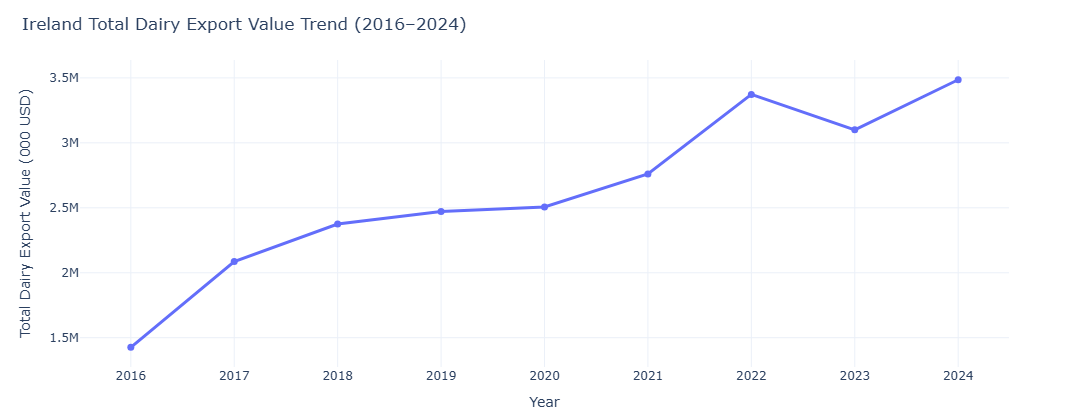

In [52]:
# Create Dash app
app = dash.Dash(
    __name__,
    external_stylesheets=[dbc.themes.BOOTSTRAP]
)

#Load data

query = """
SELECT
    country,
    year,
    total_dairy_export_value_1000USD
FROM predict_df
WHERE country = 'Ireland'
ORDER BY year
"""

ireland_df = pd.read_sql(query, engine)

# Create KPI Values
# The export column is measured in 1000 USD.
# Therefore, dividing by 1,000,000 converts the value into billion USD.
# Example: 3,485,830 (000 USD) = 3.49 billion USD.

latest_year = ireland_df['year'].max()

latest_export = ireland_df.loc[
    ireland_df['year'] == latest_year,
    'total_dairy_export_value_1000USD'
].iloc[0]

first_year = ireland_df['year'].min()

first_export = ireland_df.loc[
    ireland_df['year'] == first_year,
    'total_dairy_export_value_1000USD'
].iloc[0]

export_growth = ((latest_export - first_export) / first_export) * 100

peak_year = ireland_df.loc[
    ireland_df['total_dairy_export_value_1000USD'].idxmax(),
    'year'
]

export_2023 = ireland_df.loc[
    ireland_df['year'] == 2023,
    'total_dairy_export_value_1000USD'
].iloc[0]

recovery_growth = ((latest_export - export_2023) / export_2023) * 100


# Create export trend chart

fig = px.line(
    ireland_df,
    x='year',
    y='total_dairy_export_value_1000USD',
    title='Ireland Total Dairy Export Value Trend (2016–2024)',
    markers=True,
    labels={
        'year': 'Year',
        'total_dairy_export_value_1000USD': 'Total Dairy Export Value (000 USD)'
    }
)

fig.update_layout(template="plotly_white",hovermode="x unified",height=420,margin=dict(t=60, b=40),title_x=0.02)
fig.update_traces(line=dict(width=3),marker=dict(size=7))

In [53]:
# Load multi country export data

comparison_query = """
SELECT
    country,
    year,
    total_dairy_export_value_1000USD
FROM predict_df
ORDER BY country, year
"""

comparison_df = pd.read_sql(comparison_query, engine)

# Create multi country export comparison chart

comparison_fig = px.line(
    comparison_df,
    x='year',
    y='total_dairy_export_value_1000USD',
    color='country',
    markers=True,
    title='Comparative European Dairy Export Trends (2016–2024)',
    labels={
        'year': 'Year',
        'total_dairy_export_value_1000USD': 'Total Dairy Export Value (000 USD)',
        'country': 'Country'
    }
)

comparison_fig.update_layout(
    template='plotly_white',
    hovermode='x unified',
    height=500,
    margin=dict(t=60, b=40),
    title_x=0.02,
    legend_title='Country'
)

comparison_fig.update_traces(
    line=dict(width=3),
    marker=dict(size=6)
)


# Create dashboard layout

app.layout = dbc.Container([

    # Main dashboard title

    html.H1(
        "Ireland Agricultural Decision Intelligence Dashboard",
        className="text-center my-4"
    ),

    # Dashboard subtitle

    html.H4(
        "Agricultural Trade, Forecasting & Sentiment Analytics",
        className="text-center text-muted mb-4"
    ),

   # Add dropdown here

    dcc.Dropdown(
        id="country-filter",
        options=[
            {"label": c, "value": c}
            for c in comparison_df["country"].unique()
        ],
        value=list(comparison_df["country"].unique()),
        multi=True,
        placeholder="Select countries",
        className="mb-4"
   ),

    # Create kpi cards

    dbc.Row([

        dbc.Col(
            dbc.Card(
                dbc.CardBody([
                    html.H4(
                        f"${latest_export/1_000_000:,.2f}Bn",
                        style={
                            "fontWeight": "bold",
                            "fontSize": "2rem"
                        }
                    ),
                    html.P(f"Total Dairy Export Value ({latest_year})")
                ]),
                className="shadow-sm border-0"
            ),
            width=3
        ),

        dbc.Col(
            dbc.Card(
                dbc.CardBody([
                    html.H4(
                        f"{export_growth:.1f}%",
                        style={
                            "fontWeight": "bold",
                            "fontSize": "2rem"
                        }
                    ),
                    html.P(f"Export Growth ({first_year}–{latest_year})")
                ]),
                className="shadow-sm border-0"
            ),
            width=3
        ),

        dbc.Col(
            dbc.Card(
                dbc.CardBody([
                    html.H4(
                        f"{peak_year}",
                        style={
                            "fontWeight": "bold",
                            "fontSize": "2rem"
                        }
                    ),
                    html.P("Peak Export Year")
                ]),
                className="shadow-sm border-0"
            ),
            width=3
        ),

        dbc.Col(
            dbc.Card(
                dbc.CardBody([
                    html.H4(
                        f"{recovery_growth:.1f}%",
                        style={
                            "fontWeight": "bold",
                            "fontSize": "2rem"
                        }
                    ),
                    html.P("Export Recovery Growth (2023–2024)")
                ]),
                className="shadow-sm border-0"
            ),
            width=3
        ),

    ], className="mb-4"),

    # Create ireland export trend chart

    dcc.Graph(
        figure=fig,
        style={'marginTop': '-10px'}
    ),

    # Create ireland export insight text

    html.P(
        "Ireland’s dairy export value demonstrates sustained long-term growth between 2016 and 2024, despite temporary volatility in 2023. The trend highlights the increasing international competitiveness of Ireland’s dairy sector and supports evidence-based agricultural decision-making.",
        className="text-center mt-2 mb-4 text-muted",
        style={"maxWidth": "900px", "margin": "0 auto"}
    ),

    # Create multi country export comparison chart

    dcc.Graph(
        id="comparison-chart"
    ),

    # Create comparison insight text

    html.P(
        "Ireland demonstrates strong long-term dairy export growth relative to major European competitors. Comparative benchmarking highlights Ireland’s increasing export competitiveness within the European dairy sector and supports strategic agricultural policy evaluation.",
        className="text-center mt-2 mb-4 text-muted",
        style={"maxWidth": "900px", "margin": "0 auto"}
    )

], fluid=False)

# Create interactive callback for country filtering

@app.callback(
    Output("comparison-chart", "figure"),
    Input("country-filter", "value")
)

def update_comparison_chart(selected_countries):

    filtered_df = comparison_df[
        comparison_df["country"].isin(selected_countries)
    ]

    updated_fig = px.line(
        filtered_df,
        x='year',
        y='total_dairy_export_value_1000USD',
        color='country',
        markers=True,
        title='Comparative European Dairy Export Trends (2016–2024)',
        labels={
            'year': 'Year',
            'total_dairy_export_value_1000USD': 'Total Dairy Export Value (000 USD)',
            'country': 'Country'
        }
    )

    updated_fig.update_layout(
        template='plotly_white',
        hovermode='x unified',
        height=500,
        margin=dict(t=60, b=40),
        title_x=0.02,
        legend_title='Country'
    )

    updated_fig.update_traces(
        line=dict(width=3),
        marker=dict(size=6)
    )

    return updated_fig

app.run(debug=True)